# Task 1: Data Cleaning & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Handling missing values

In [9]:
df["Age"].fillna(df["Age"].median(), inplace=True)

In [10]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

In [11]:
df["Has_Cabin"] = df["Cabin"].notna().astype(int)
df.drop(columns=["Cabin"], inplace=True)

Dropping columns that are not useful

In [12]:
df.drop(columns=["PassengerId", "Name", "Ticket"], inplace=True)

In [13]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0
5,0,3,male,28.0,0,0,8.4583,Q,0
6,0,1,male,54.0,0,0,51.8625,S,1
7,0,3,male,2.0,3,1,21.0750,S,0
8,1,3,female,27.0,0,2,11.1333,S,0
9,1,2,female,14.0,1,0,30.0708,C,0


In [14]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Has_Cabin,0


Encoding Categorical Columns

In [15]:
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

In [ ]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

Standardize Numerical Features

In [17]:
scaler = StandardScaler()
num_cols = ["Age", "Fare", "SibSp", "Parch"]
df[num_cols] = scaler.fit_transform(df[num_cols])

Visualize & Remove Outliers

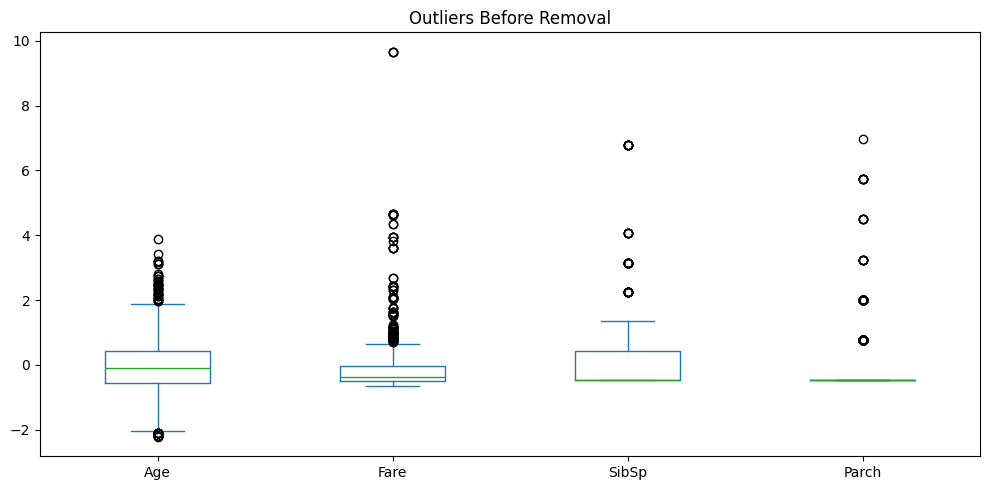

In [18]:
df[num_cols].plot(kind="box", figsize=(10, 5), title="Outliers Before Removal")
plt.tight_layout()
plt.show()

In [19]:
# Remove outliers using IQR method
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df  = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

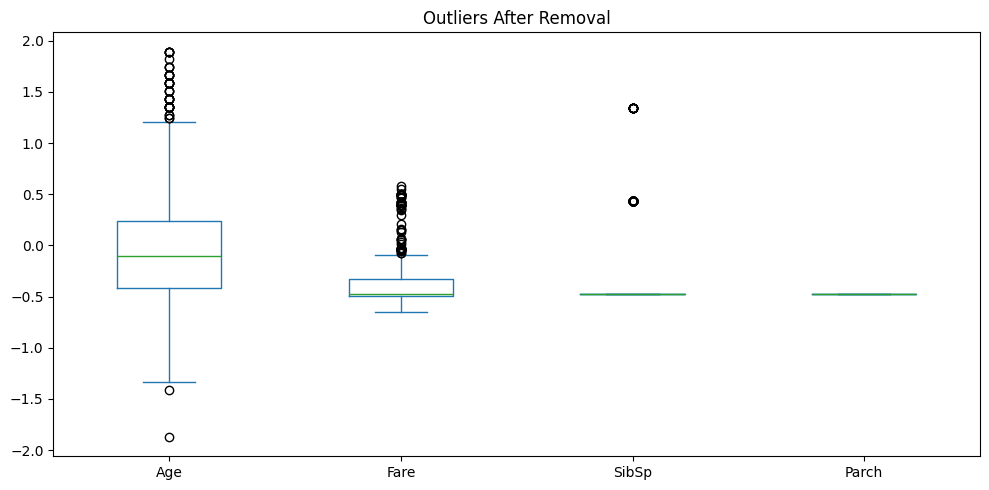

In [20]:
# Boxplots AFTER removal
df[num_cols].plot(kind="box", figsize=(10, 5), title="Outliers After Removal")
plt.tight_layout()
plt.show()

In [21]:

print("Final shape:", df.shape)

Final shape: (577, 10)


In [22]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin
count,577.000000,577.000000,577.000000,577.000000,577.000000,5.770000e+02,577.000000,577.000000
mean,0.299827,2.502600,0.752166,-0.004480,-0.293706,-4.736736e-01,-0.347884,0.135182
std,0.458579,0.733909,0.432129,0.657194,0.403796,2.777966e-16,0.253828,0.342215
min,0.000000,1.000000,0.000000,-1.872184,-0.474545,-4.736736e-01,-0.648422,0.000000
25%,0.000000,2.000000,1.000000,-0.412037,-0.474545,-4.736736e-01,-0.491874,0.000000
50%,0.000000,3.000000,1.000000,-0.104637,-0.474545,-4.736736e-01,-0.474005,0.000000
75%,1.000000,3.000000,1.000000,0.241187,-0.474545,-4.736736e-01,-0.329287,0.000000
max,1.000000,3.000000,1.000000,1.893459,1.340132,-4.736736e-01,0.583318,1.000000


In [28]:

df[["Embarked_Q", "Embarked_S"]] = df[["Embarked_Q", "Embarked_S"]].astype(int)

In [24]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Has_Cabin,0
Embarked_Q,0
Embarked_S,0


Therefore there are no null values and no outliers in the final dataset

In [29]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin,Embarked_Q,Embarked_S
0,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,0,0,1
2,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,0,0,1
3,1,1,0,0.433312,0.432793,-0.473674,0.420730,1,0,1
4,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,0,0,1
5,0,3,1,-0.104637,-0.474545,-0.473674,-0.478116,0,1,0
...,...,...,...,...,...,...,...,...,...,...
884,0,3,1,-0.335187,-0.474545,-0.473674,-0.506472,0,0,1
886,0,2,1,-0.181487,-0.474545,-0.473674,-0.386671,0,0,1
887,1,1,0,-0.796286,-0.474545,-0.473674,-0.044381,1,0,1
889,1,1,1,-0.258337,-0.474545,-0.473674,-0.044381,1,0,0
